# 04 — SHAP Explainability

Global and local SHAP explanations for the best insider-threat model. Beeswarm, bar, and waterfall plots plus a plain-English risk report.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from src.feature_engineering import aggregate_user_features
from src.explain import (
    generate_shap_values,
    plot_shap_summary,
    plot_shap_bar,
    explain_single_prediction,
    find_high_risk_user,
    generate_shap_report,
)

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('../data/synthetic_cert.csv', parse_dates=['date'])
feats = aggregate_user_features(df)
feat_cols = [c for c in feats.columns if c not in ('user_id', 'label')]
X = feats[feat_cols]
y = feats['label']

model = joblib.load('../outputs/best_model.pkl')
print(f'Loaded model: {model.named_steps["clf"].__class__.__name__}')
print(f'Feature matrix: {X.shape}')

Loaded model: LogisticRegression
Feature matrix: (2000, 52)


In [3]:
shap_vals, explainer = generate_shap_values(model, X)

## 1. Beeswarm Summary Plot

Each dot is one user; colour = feature value (red high, blue low); x-axis = SHAP impact on threat probability.

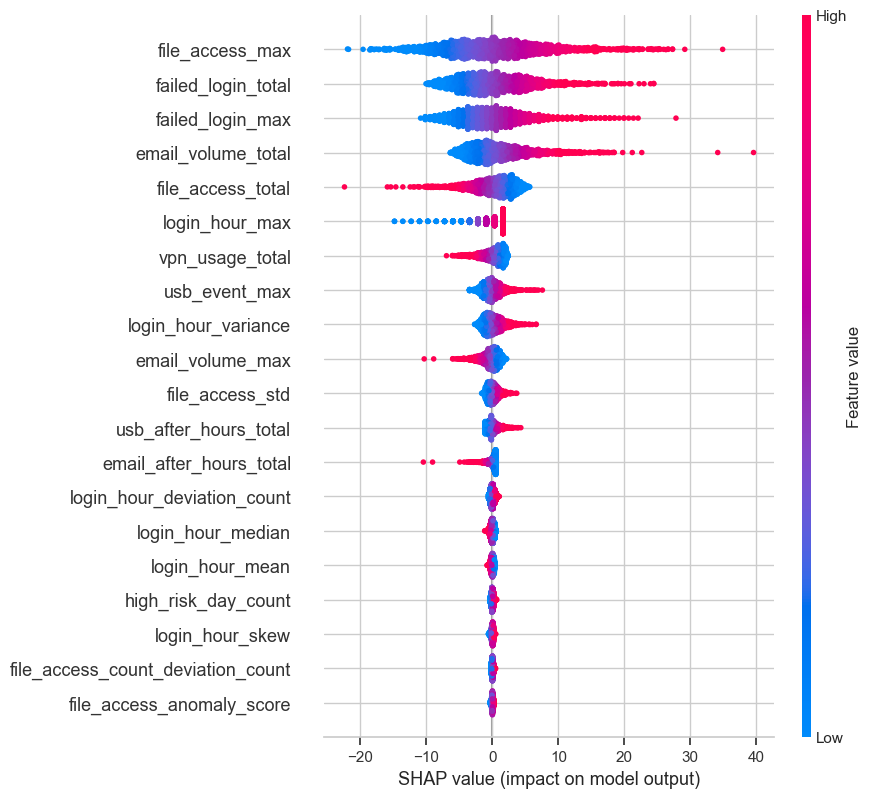

In [4]:
plot_shap_summary(shap_vals, X, '../outputs/shap_beeswarm.png')

## 2. Mean |SHAP| Bar Plot

Global feature importance ranked by average absolute impact.

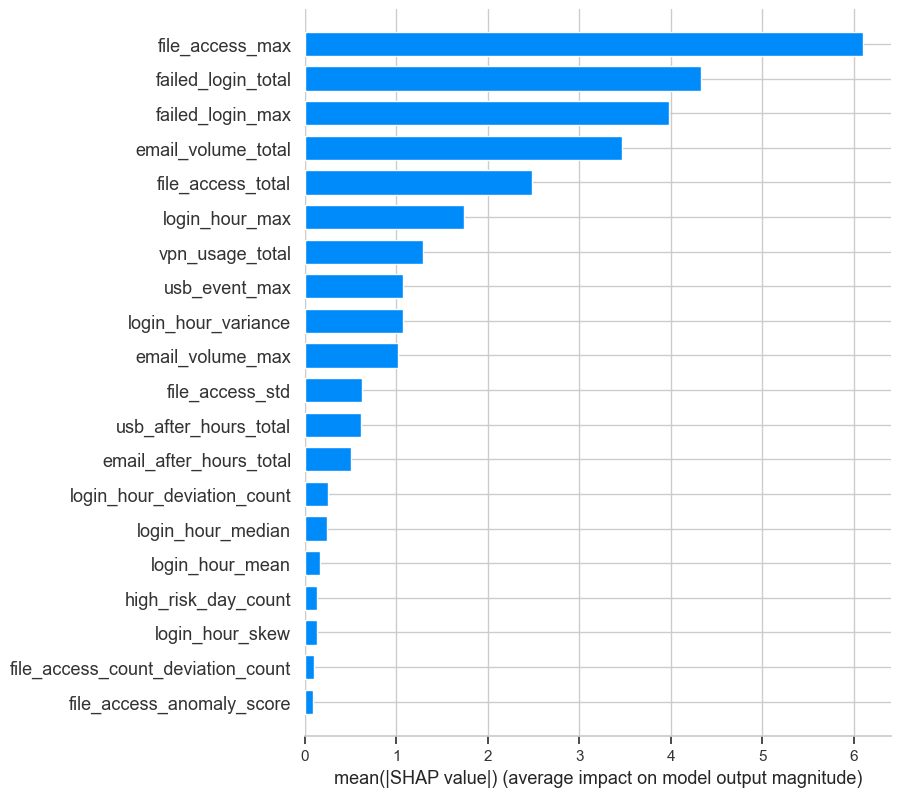

In [5]:
plot_shap_bar(shap_vals, X, '../outputs/shap_bar.png')

## 3. Waterfall — Single High-Risk User

Highest-risk user index: 0


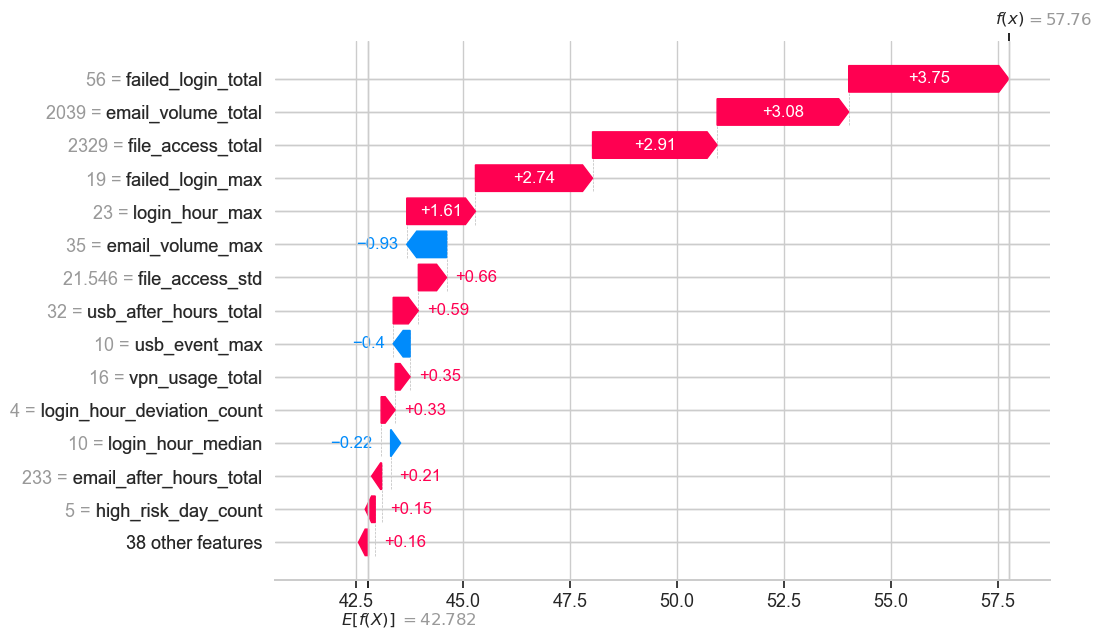

Predicted threat probability: 1.0000


In [6]:
idx = find_high_risk_user(model, X)
print(f'Highest-risk user index: {idx}')
result = explain_single_prediction(model, X, idx, '../outputs/shap_waterfall.png')
print(f'Predicted threat probability: {result["predicted_probability"]:.4f}')

## 4. Plain-English Risk Report

In [7]:
report = generate_shap_report(shap_vals, X, top_n=10, output_path='../outputs/shap_report.md')
from IPython.display import Markdown
Markdown(report)

SHAP report written to ../outputs/shap_report.md


# SHAP Explainability Report

Top 10 risk indicators ranked by mean absolute SHAP value.

| Rank | Feature | Mean \|SHAP\| | Direction | Risk Rationale |
|------|---------|--------------|-----------|----------------|
| 1 | `file_access_max` | 6.104826 | Increases risk ↑ | Unusual file-access counts or patterns indicate data staging, bulk download, or intellectual-property theft. |
| 2 | `failed_login_total` | 4.328533 | Increases risk ↑ | Multiple failed login attempts suggest credential probing, privilege escalation, or unauthorised system access. |
| 3 | `failed_login_max` | 3.981897 | Decreases risk ↓ | Multiple failed login attempts suggest credential probing, privilege escalation, or unauthorised system access. |
| 4 | `email_volume_total` | 3.472144 | Increases risk ↑ | Sudden spikes in email volume can reflect bulk data exfiltration to personal accounts. |
| 5 | `file_access_total` | 2.482799 | Increases risk ↑ | Unusual file-access counts or patterns indicate data staging, bulk download, or intellectual-property theft. |
| 6 | `login_hour_max` | 1.737118 | Increases risk ↑ | Irregular login times — especially late-night or early-morning — correlate with stealthy insider behaviour. |
| 7 | `vpn_usage_total` | 1.299128 | Increases risk ↑ | VPN usage can mask a user's true location, enabling covert activity from untrusted networks. |
| 8 | `usb_event_max` | 1.080252 | Decreases risk ↓ | USB mass-storage device usage is the most common physical exfiltration vector for sensitive data. |
| 9 | `login_hour_variance` | 1.073646 | Increases risk ↑ | Irregular login times — especially late-night or early-morning — correlate with stealthy insider behaviour. |
| 10 | `email_volume_max` | 1.022684 | Decreases risk ↓ | Sudden spikes in email volume can reflect bulk data exfiltration to personal accounts. |

---

### Detailed Explanations

**1. `file_access_max`** (mean |SHAP| = 6.104826)  
   This feature **increases** the predicted threat probability. 
   Unusual file-access counts or patterns indicate data staging, bulk download, or intellectual-property theft.

**2. `failed_login_total`** (mean |SHAP| = 4.328533)  
   This feature **increases** the predicted threat probability. 
   Multiple failed login attempts suggest credential probing, privilege escalation, or unauthorised system access.

**3. `failed_login_max`** (mean |SHAP| = 3.981897)  
   This feature **decreases** the predicted threat probability. 
   Multiple failed login attempts suggest credential probing, privilege escalation, or unauthorised system access.

**4. `email_volume_total`** (mean |SHAP| = 3.472144)  
   This feature **increases** the predicted threat probability. 
   Sudden spikes in email volume can reflect bulk data exfiltration to personal accounts.

**5. `file_access_total`** (mean |SHAP| = 2.482799)  
   This feature **increases** the predicted threat probability. 
   Unusual file-access counts or patterns indicate data staging, bulk download, or intellectual-property theft.

**6. `login_hour_max`** (mean |SHAP| = 1.737118)  
   This feature **increases** the predicted threat probability. 
   Irregular login times — especially late-night or early-morning — correlate with stealthy insider behaviour.

**7. `vpn_usage_total`** (mean |SHAP| = 1.299128)  
   This feature **increases** the predicted threat probability. 
   VPN usage can mask a user's true location, enabling covert activity from untrusted networks.

**8. `usb_event_max`** (mean |SHAP| = 1.080252)  
   This feature **decreases** the predicted threat probability. 
   USB mass-storage device usage is the most common physical exfiltration vector for sensitive data.

**9. `login_hour_variance`** (mean |SHAP| = 1.073646)  
   This feature **increases** the predicted threat probability. 
   Irregular login times — especially late-night or early-morning — correlate with stealthy insider behaviour.

**10. `email_volume_max`** (mean |SHAP| = 1.022684)  
   This feature **decreases** the predicted threat probability. 
   Sudden spikes in email volume can reflect bulk data exfiltration to personal accounts.


## Summary

- **`file_access_max`** is the single most impactful feature (mean |SHAP| ≈ 6.1).
- **`failed_login_total`** and **`email_volume_total`** follow as strong risk indicators.
- The waterfall plot shows how individual features push a specific user's score above the population baseline.
- The SHAP report (`outputs/shap_report.md`) captures all top-10 indicators with plain-English rationale suitable for SOC analysts.